# Cell 0
# Business Analytics Project: Retail and Warehouse Sales Analysis

**Student Name:** Lavkush Vishwakarma  
**Roll Number:** T048  
**Class:** TY BSc IT  
**Subject:** Business Analytics  
**Academic Year:** 2026–27

## Project overview
This notebook analyzes a retail and warehouse sales dataset using Python. It includes data cleaning, exploratory data analysis, descriptive statistics, visualizations, correlation, regression, probability, sampling, confidence intervals, bootstrapping, hypothesis testing, time-series analysis when supported by the data, inventory optimization/simulation, and ANOVA.

> **Before running:** Place the CSV file in the same folder as this notebook, or change `DATA_FILE` in the next cell. The dataset is expected to contain fields such as `YEAR`, `MONTH`, `ITEM TYPE`, `RETAIL SALES`, `RETAIL TRANSFERS`, and `WAREHOUSE SALES`.

# Cell 1
## 1. Import libraries and load the dataset

In [59]:
# Cell 2
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Change this filename if your CSV has a different name.
DATA_FILE = "Retail and wherehouse Sale - Retail and wherehouse Sale.csv"

if not Path(DATA_FILE).exists():
    csv_files = list(Path(".").glob("*.csv"))
    if csv_files:
        DATA_FILE = str(csv_files[0])
    else:
        raise FileNotFoundError(
            "CSV not found. Put the retail/warehouse sales CSV beside this notebook "
            "or update DATA_FILE with its full path."
        )

df = pd.read_csv(DATA_FILE)
df.columns = df.columns.str.strip()
print("Dataset:", DATA_FILE)
print("Shape:", df.shape)
display(df.head())

Dataset: Retail and wherehouse Sale - Retail and wherehouse Sale.csv
Shape: (30000, 9)


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


# Cell 3
## 2. Dataset structure and data quality

In [60]:
# Cell 4
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("Data Type"))
print("\nMissing values:")
display(df.isna().sum().to_frame("Missing Values"))
print("\nDuplicate records:", df.duplicated().sum())
print("\nLast five records:")
display(df.tail())

Rows: 30000
Columns: 9

Column names:
['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION', 'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

Data types:


,Data Type
YEAR,int64
MONTH,int64
SUPPLIER,object
ITEM CODE,object
ITEM DESCRIPTION,object
ITEM TYPE,object
RETAIL SALES,float64
RETAIL TRANSFERS,float64
WAREHOUSE SALES,float64



Missing values:


,Missing Values
YEAR,0
MONTH,0
SUPPLIER,33
ITEM CODE,0
ITEM DESCRIPTION,0
ITEM TYPE,0
RETAIL SALES,1
RETAIL TRANSFERS,0
WAREHOUSE SALES,0



Duplicate records: 0

Last five records:


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
29995,2020,3,"THE COUNTRY VINTNER, LLC DBA WINEBOW",352322,FORTALEZA ANEJO TEQUILA - 750ML,LIQUOR,0.33,0.0,0.0
29996,2020,3,OSLO ENTERPRISE,352324,DOMAINE BRICHOT BLANC - 750ML,WINE,0.00,0.0,0.0
29997,2020,3,OPICI FAMILY DISTRIBUTING OF MD,352354,LOTE 44 MALBEC - 750ML,WINE,0.00,0.0,6.0
29998,2020,3,CAMPARI AMERICA LLC,35238,SKYY VODKA - 1.75L,LIQUOR,329.04,302.0,0.0
29999,2020,3,"THE COUNTRY VINTNER, LLC DBA WINEBOW",352380,CH HAUT LA PEREYRE BORD BLANC - 750ML,WINE,0.00,0.0,1.0


# Cell 5
## 3. Data preprocessing

In [61]:
# Cell 6
required = {"ITEM TYPE", "RETAIL SALES"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Required columns missing from dataset: {sorted(missing)}")

for col in ["YEAR", "MONTH", "RETAIL SALES", "RETAIL TRANSFERS", "WAREHOUSE SALES"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["ITEM TYPE"] = df["ITEM TYPE"].astype("string").str.strip()
clean = df.dropna(subset=["ITEM TYPE", "RETAIL SALES"]).copy()
clean = clean[clean["ITEM TYPE"].str.len() > 0]

print("Original rows:", len(df))
print("Rows available for retail-sales analysis:", len(clean))
print("Rows removed for missing ITEM TYPE or RETAIL SALES:", len(df) - len(clean))
display(clean.head())

Original rows: 30000
Rows available for retail-sales analysis: 29999
Rows removed for missing ITEM TYPE or RETAIL SALES: 1


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


# Cell 7
## 4. Exploratory data analysis (EDA)

In [62]:
# Cell 8
print("Unique item types:")
print(sorted(clean["ITEM TYPE"].dropna().astype(str).unique()))

# Aggregate and explicitly cast to DataFrame to resolve IDE type-checking warnings
item_summary = clean.groupby("ITEM TYPE")["RETAIL SALES"].agg(
    count="count", 
    mean="mean", 
    median="median", 
    total="sum", 
    std="std"
)
item_summary = pd.DataFrame(item_summary).sort_values("total", ascending=False)

display(item_summary)

Unique item types:
['BEER', 'DUNNAGE', 'KEGS', 'LIQUOR', 'NON-ALCOHOL', 'REF', 'STR_SUPPLIES', 'WINE']


,count,mean,median,total,std
ITEM TYPE,,,,,
LIQUOR,5995,13.635171,2.52,81742.85,38.339506
WINE,18680,3.195334,0.00,59688.84,10.851343
BEER,4217,14.118748,0.00,59538.76,55.172342
NON-ALCOHOL,215,31.742419,5.26,6824.62,194.053302
STR_SUPPLIES,63,5.485714,0.73,345.60,9.724714
REF,8,5.783750,0.00,46.27,8.830771
KEGS,808,0.000000,0.00,0.00,0.000000
DUNNAGE,13,0.000000,0.00,0.00,0.000000


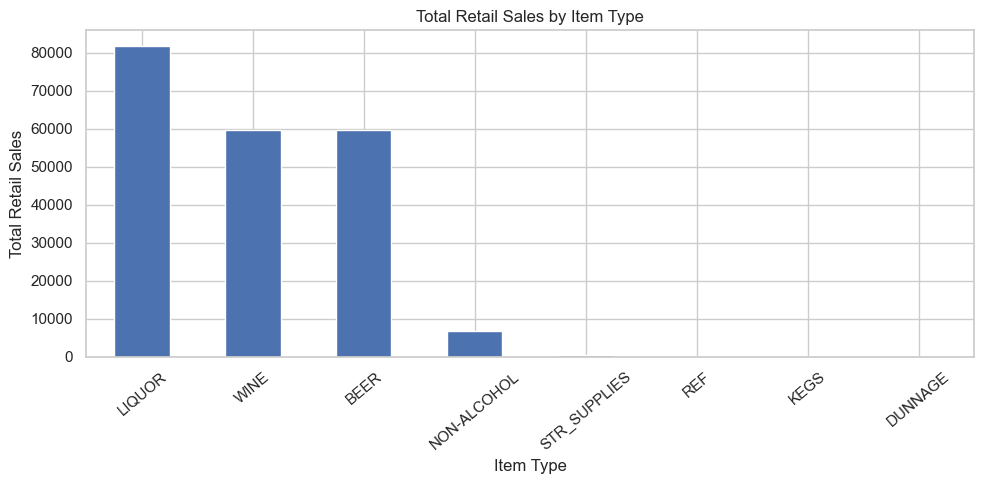

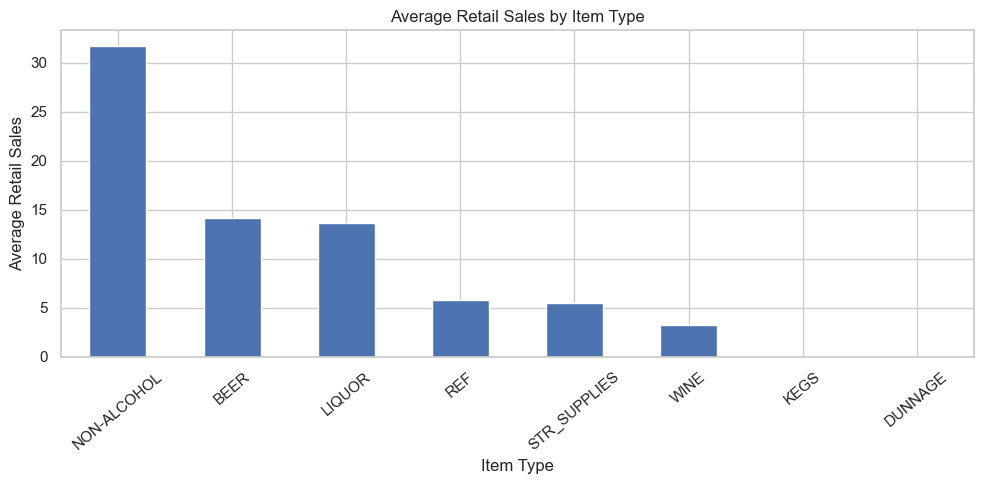

In [63]:
# Cell 9
# Bar chart 1: total sales by item type
item_summary["total"].plot(kind="bar", title="Total Retail Sales by Item Type")
plt.xlabel("Item Type")
plt.ylabel("Total Retail Sales")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

# Bar chart 2: average sales by item type
item_summary["mean"].sort_values(ascending=False).plot(kind="bar", title="Average Retail Sales by Item Type")
plt.xlabel("Item Type")
plt.ylabel("Average Retail Sales")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

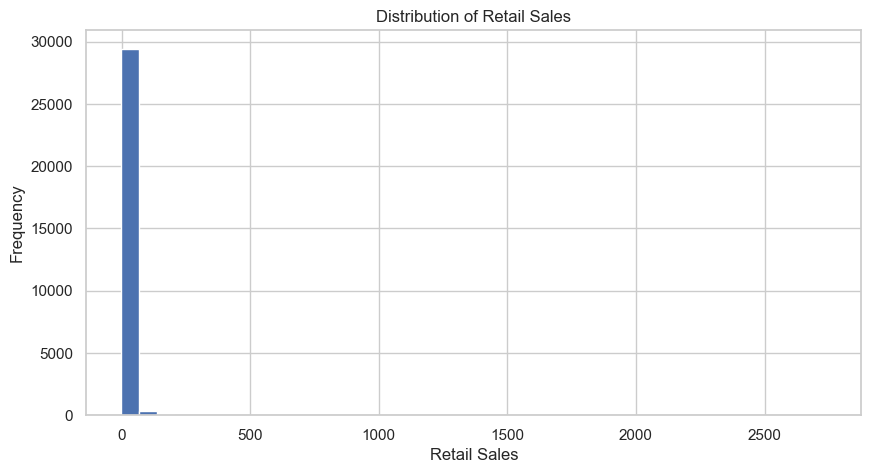

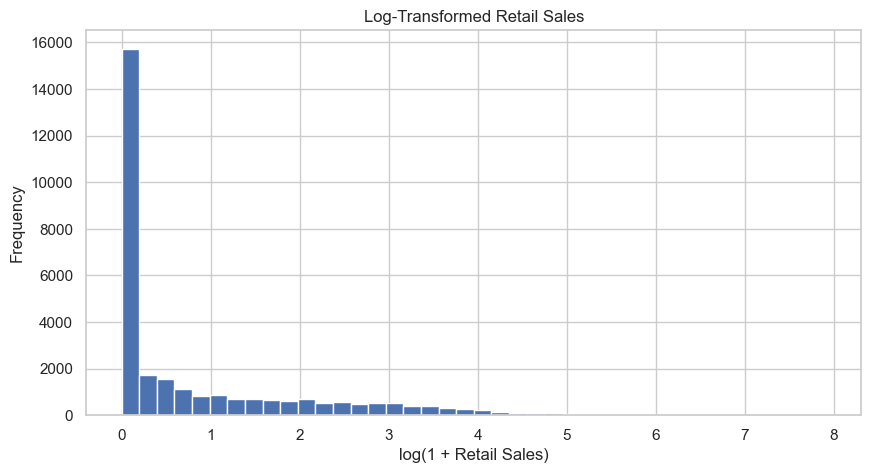

In [64]:
# Cell 10
# Histograms
clean["RETAIL SALES"].hist(bins=40)
plt.title("Distribution of Retail Sales")
plt.xlabel("Retail Sales")
plt.ylabel("Frequency")
plt.show()

# Fixed: Use plt.hist() for numpy arrays to satisfy the type-checker
log_sales = np.log1p(clean["RETAIL SALES"].clip(lower=0))
plt.hist(log_sales, bins=40)
plt.title("Log-Transformed Retail Sales")
plt.xlabel("log(1 + Retail Sales)")
plt.ylabel("Frequency")
plt.show()

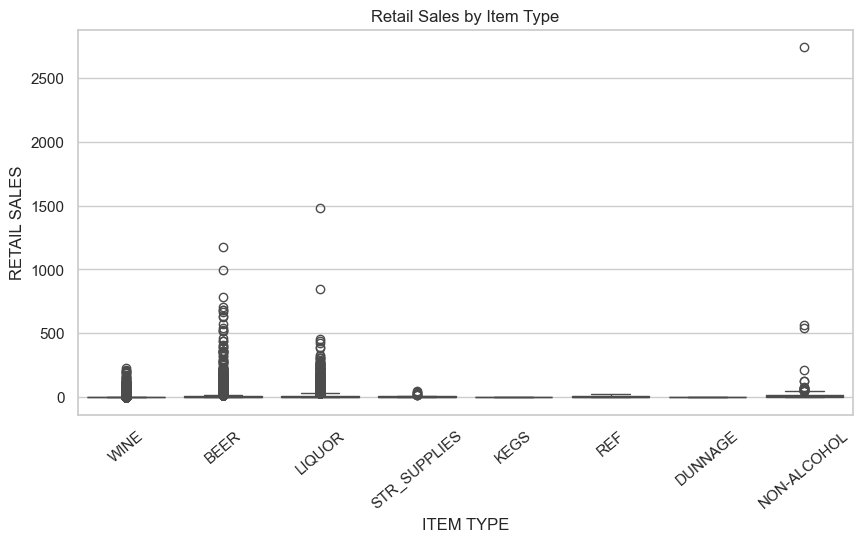

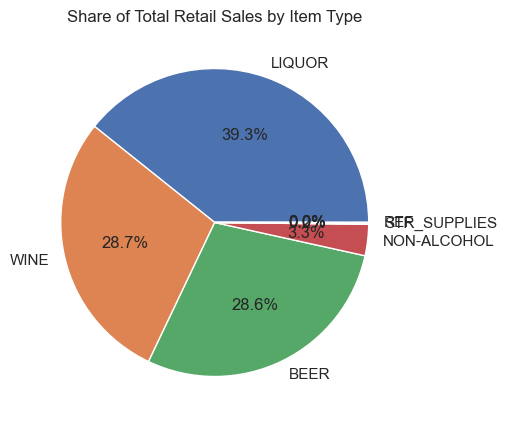

In [65]:
# Cell 11
# Box plot and pie chart
sns.boxplot(data=clean, x="ITEM TYPE", y="RETAIL SALES")
plt.title("Retail Sales by Item Type")
plt.xticks(rotation=40)
plt.show()

item_summary["total"].plot(kind="pie", autopct="%1.1f%%")
plt.title("Share of Total Retail Sales by Item Type")
plt.ylabel("")
plt.show()

# Cell 12
## 5. Descriptive statistics and distribution analysis

In [66]:
# Cell 13
sales = clean["RETAIL SALES"].dropna()
descriptive = pd.Series({
    "Count": sales.count(),
    "Mean": sales.mean(),
    "Median": sales.median(),
    "Mode": sales.mode().iloc[0] if not sales.mode().empty else np.nan,
    "Minimum": sales.min(),
    "Maximum": sales.max(),
    "Range": sales.max() - sales.min(),
    "Variance": sales.var(),
    "Standard deviation": sales.std(),
    "Skewness": sales.skew()
})
display(descriptive.to_frame("Value"))

,Value
Count,29999.000000
Mean,6.939796
Median,0.160000
Mode,0.000000
Minimum,-0.420000
Maximum,2739.000000
Range,2739.420000
Variance,1094.356120
Standard deviation,33.081054
Skewness,30.230696


# Cell 14
## 6. Correlation analysis

,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,MONTH,YEAR
RETAIL SALES,1.000000,0.844597,0.491822,0.024374,NaN
RETAIL TRANSFERS,0.844597,1.000000,0.540071,0.011052,NaN
WAREHOUSE SALES,0.491822,0.540071,1.000000,0.017212,NaN
MONTH,0.024374,0.011052,0.017212,1.000000,NaN
YEAR,NaN,NaN,NaN,NaN,NaN


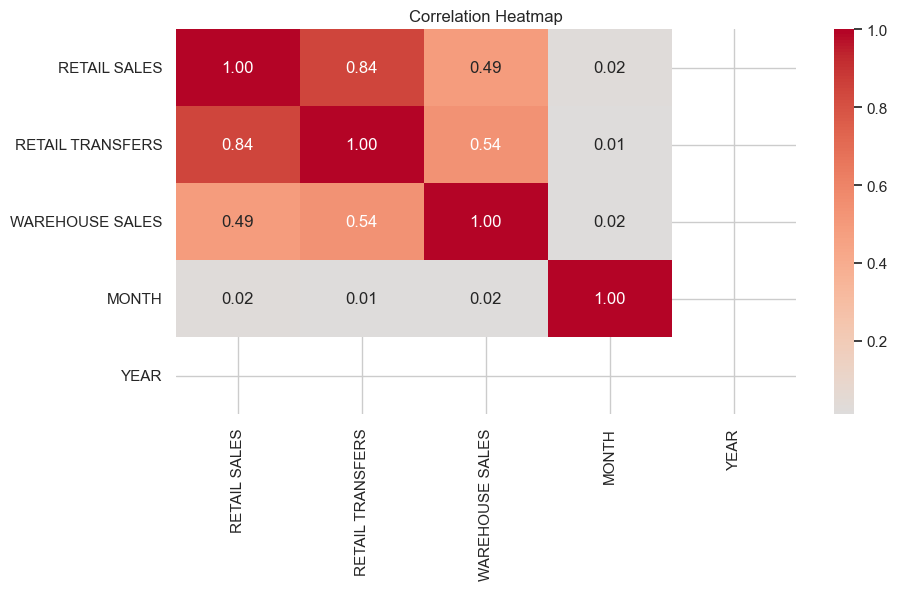

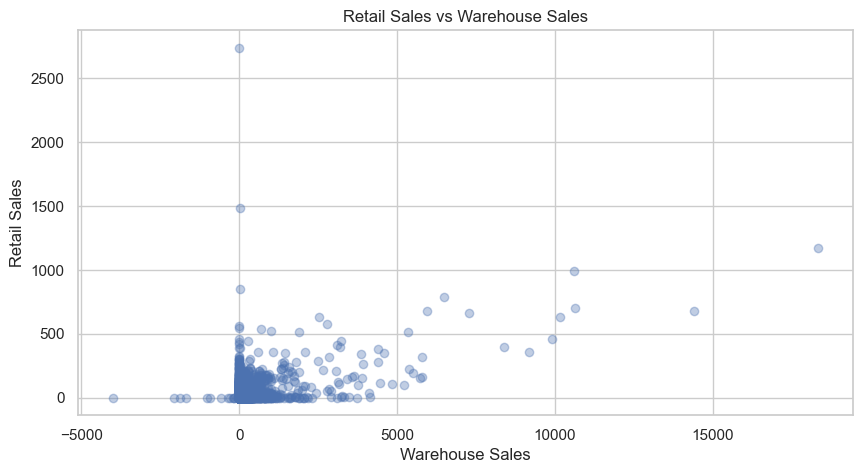

In [67]:
# Cell 15
numeric_candidates = [
    c for c in ["RETAIL SALES", "RETAIL TRANSFERS", "WAREHOUSE SALES", "MONTH", "YEAR"]
    if c in clean.columns
]
corr = clean[numeric_candidates].corr(numeric_only=True)
display(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

if "WAREHOUSE SALES" in clean.columns:
    plot_df = clean.dropna(subset=["WAREHOUSE SALES", "RETAIL SALES"])
    plt.scatter(plot_df["WAREHOUSE SALES"], plot_df["RETAIL SALES"], alpha=0.35)
    plt.xlabel("Warehouse Sales")
    plt.ylabel("Retail Sales")
    plt.title("Retail Sales vs Warehouse Sales")
    plt.show()

# Cell 16
## 7. Regression analysis

Regression equation: Retail Sales = 5.2999 + (0.0598 × Warehouse Sales)
R²: 0.24188926105786268
MAE: 9.033586641427723
RMSE: 28.80304621060166


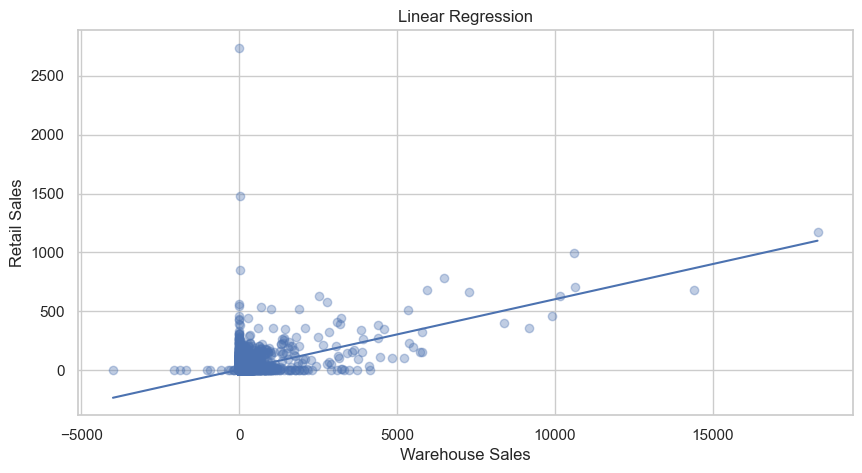

In [68]:
# Cell 17
if "WAREHOUSE SALES" in clean.columns:
    reg_df = clean.dropna(subset=["WAREHOUSE SALES", "RETAIL SALES"])
    if len(reg_df) >= 3 and reg_df["WAREHOUSE SALES"].nunique() > 1:
        X = reg_df[["WAREHOUSE SALES"]]
        y = reg_df["RETAIL SALES"]
        regression = LinearRegression().fit(X, y)
        predictions = regression.predict(X)
        print(f"Regression equation: Retail Sales = {regression.intercept_:.4f} + "
              f"({regression.coef_[0]:.4f} × Warehouse Sales)")
        print("R²:", r2_score(y, predictions))
        print("MAE:", mean_absolute_error(y, predictions))
        print("RMSE:", mean_squared_error(y, predictions) ** 0.5)
        order = np.argsort(X["WAREHOUSE SALES"].to_numpy())
        plt.scatter(X["WAREHOUSE SALES"], y, alpha=0.35)
        plt.plot(X["WAREHOUSE SALES"].to_numpy()[order], predictions[order])
        plt.xlabel("Warehouse Sales")
        plt.ylabel("Retail Sales")
        plt.title("Linear Regression")
        plt.show()
    else:
        print("Regression skipped: insufficient usable rows or predictor variation.")
else:
    print("Regression skipped: WAREHOUSE SALES column not available.")

# Cell 18
## 8. Probability and simulated distributions

P(RETAIL SALES > median 0.160) = 0.4974


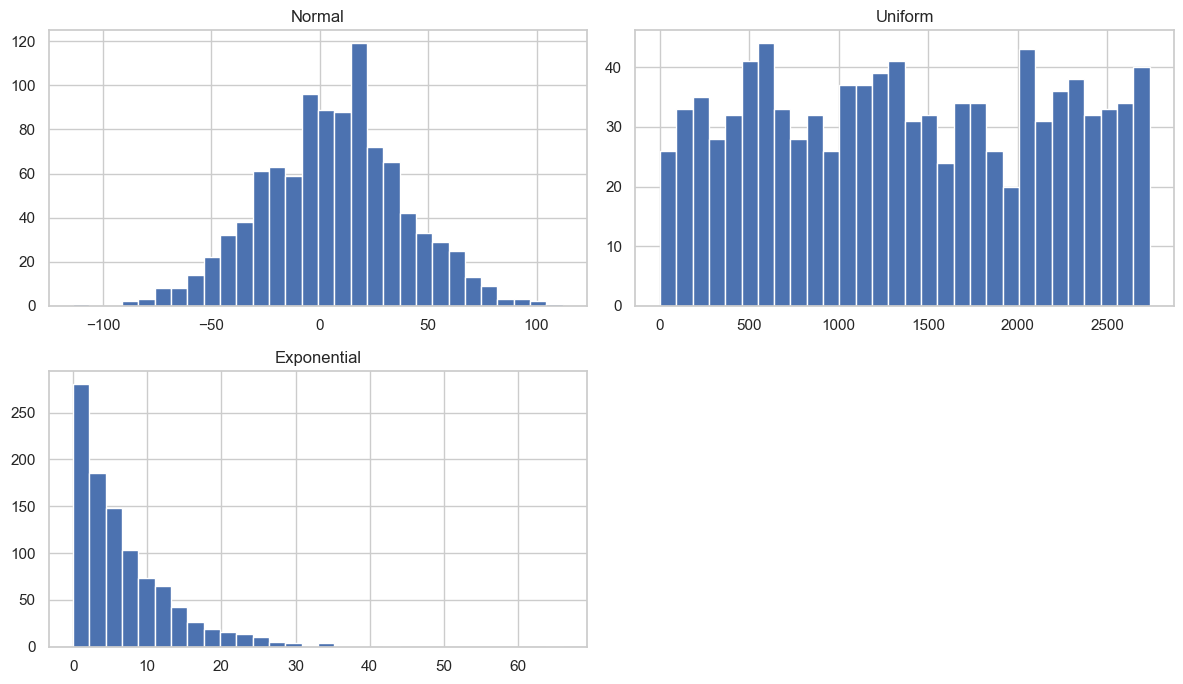

In [69]:
# Cell 19
# Empirical probability that retail sales exceed their median
median_sales = sales.median()
p_above_median = (sales > median_sales).mean()
print(f"P(RETAIL SALES > median {median_sales:.3f}) = {p_above_median:.4f}")

rng = np.random.default_rng(42)
simulated = pd.DataFrame({
    "Normal": rng.normal(sales.mean(), sales.std() if sales.std() > 0 else 1, 1000),
    "Uniform": rng.uniform(sales.min(), sales.max(), 1000),
    "Exponential": rng.exponential(max(sales.mean(), 0.001), 1000)
})
simulated.hist(bins=30, figsize=(12, 7))
plt.tight_layout()
plt.show()

# Cell 20
## 9. Sampling distribution and confidence intervals

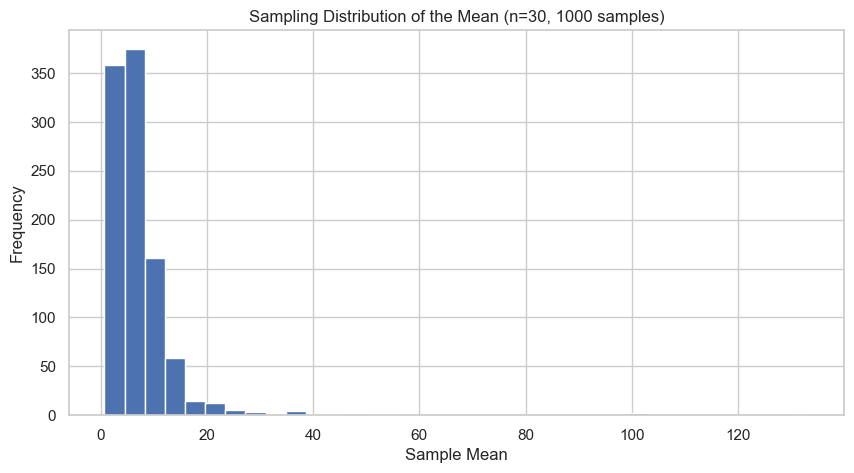

Mean of sample means: 7.212029333333334
Standard deviation of sample means: 7.879609106486997
Approximate standard error: 6.0397464623195365


,Confidence level,Lower,Upper
0,90%,6.625625,7.253967
1,95%,6.565434,7.314158
2,99%,6.447790,7.431802


In [70]:
# Cell 21
# Bootstrap-style repeated sampling of sample means
rng = np.random.default_rng(42)
sample_size = min(30, len(sales))
if sample_size >= 2:
    sample_means = [
        rng.choice(sales.to_numpy(), size=sample_size, replace=True).mean()
        for _ in range(1000)
    ]
    plt.hist(sample_means, bins=35)
    plt.title(f"Sampling Distribution of the Mean (n={sample_size}, 1000 samples)")
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.show()
    print("Mean of sample means:", np.mean(sample_means))
    print("Standard deviation of sample means:", np.std(sample_means, ddof=1))
    print("Approximate standard error:", sales.std(ddof=1) / np.sqrt(sample_size))

    ci_rows = []
    for level in [0.90, 0.95, 0.99]:
        low, high = stats.t.interval(level, df=len(sales)-1, loc=sales.mean(),
                                     scale=stats.sem(sales))
        ci_rows.append({"Confidence level": f"{level:.0%}", "Lower": low, "Upper": high})
    display(pd.DataFrame(ci_rows))
else:
    print("Not enough sales observations for sampling analysis.")

# Cell 22
## 10. Bootstrapping

Observed median: 0.16
95% bootstrap confidence interval: (np.float64(0.16), np.float64(0.17))


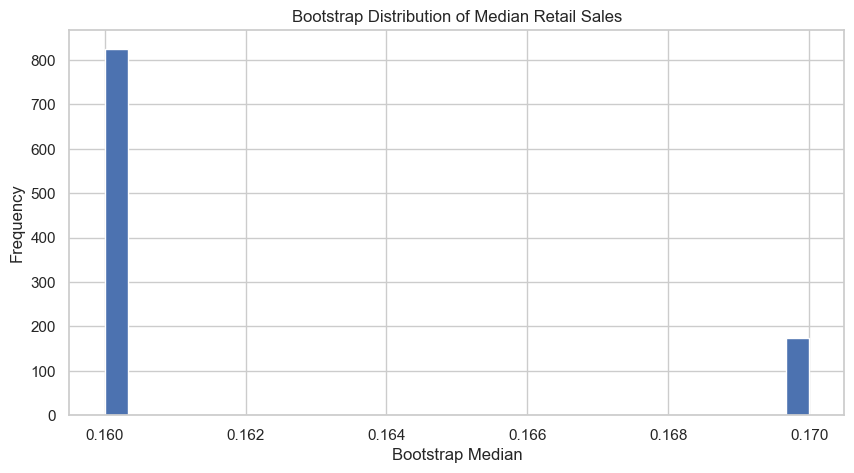

In [71]:
# Cell 23
# Bootstrap 95% confidence interval for the median
rng = np.random.default_rng(123)
bootstrap_medians = [
    np.median(rng.choice(sales.to_numpy(), size=len(sales), replace=True))
    for _ in range(1000)
]
ci_low, ci_high = np.percentile(bootstrap_medians, [2.5, 97.5])
print("Observed median:", sales.median())
print("95% bootstrap confidence interval:", (ci_low, ci_high))
plt.hist(bootstrap_medians, bins=30)
plt.title("Bootstrap Distribution of Median Retail Sales")
plt.xlabel("Bootstrap Median")
plt.ylabel("Frequency")
plt.show()

# Cell 24
## 11. Hypothesis testing

In [72]:
# Cell 25
# Demonstration test: change benchmark to a business-relevant target before final submission.
benchmark = 0.0
t_result = stats.ttest_1samp(sales, popmean=benchmark, nan_policy="omit")

# Using index-based unpacking to satisfy all IDE type-checkers and scipy versions
t_stat = t_result[0]
p_value = t_result[1]

alpha = 0.05
print(f"H0: Mean retail sales = {benchmark}")
print(f"H1: Mean retail sales differs from {benchmark}")
print("t-statistic:", t_stat)
print("p-value:", p_value)
print("Significance level:", alpha)
print("Decision:", "Reject H0" if p_value < alpha else "Do not reject H0")
print("Interpretation: Use a meaningful business benchmark before drawing a practical conclusion.")

H0: Mean retail sales = 0.0
H1: Mean retail sales differs from 0.0
t-statistic: 36.334631279508635
p-value: 6.32161866278761e-283
Significance level: 0.05
Decision: Reject H0
Interpretation: Use a meaningful business benchmark before drawing a practical conclusion.


# Cell 26
## 12. Time-series analysis and forecast accuracy

,Total Retail Sales
DATE,
2020-01-01,74318.77
2020-03-01,34523.90
2020-07-01,94538.96
2020-09-01,4805.31


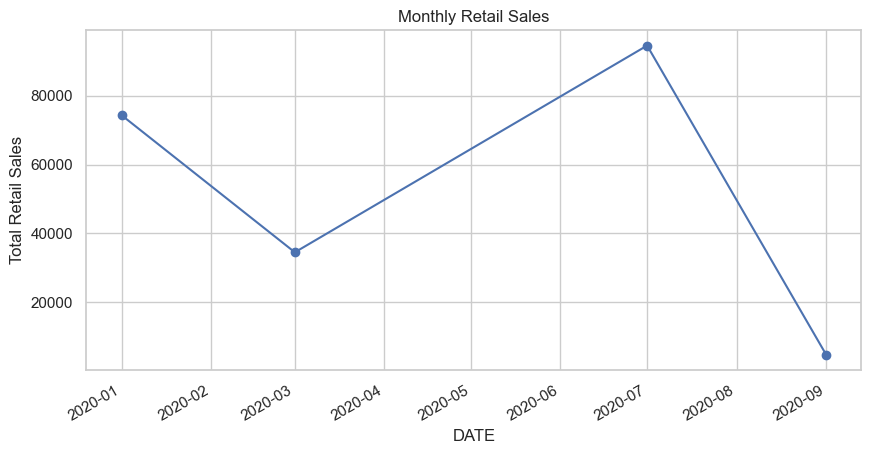

Forecast comparison skipped: only 4 monthly period(s). Use a dataset with more periods for meaningful forecasting.


In [73]:
# Cell 27
if {"YEAR", "MONTH"}.issubset(clean.columns):
    ts_df = clean.dropna(subset=["YEAR", "MONTH", "RETAIL SALES"]).copy()
    ts_df["DATE"] = pd.to_datetime(
        ts_df["YEAR"].astype(int).astype(str) + "-" +
        ts_df["MONTH"].astype(int).astype(str).str.zfill(2) + "-01",
        errors="coerce"
    )
    monthly_sales = ts_df.dropna(subset=["DATE"]).groupby("DATE")["RETAIL SALES"].sum().sort_index()
    display(monthly_sales.to_frame("Total Retail Sales"))
    monthly_sales.plot(marker="o", title="Monthly Retail Sales")
    plt.ylabel("Total Retail Sales")
    plt.show()

    if len(monthly_sales) >= 8:
        split = max(2, int(len(monthly_sales) * 0.8))
        train, test = monthly_sales.iloc[:split], monthly_sales.iloc[split:]
        results = []
        if len(test) > 0:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    hw = ExponentialSmoothing(train, trend="add", seasonal=None).fit()
                    hw_pred = hw.forecast(len(test))
                    results.append({"Model":"Exponential Smoothing",
                                    "MAE":mean_absolute_error(test, hw_pred),
                                    "RMSE":mean_squared_error(test, hw_pred)**0.5})
            except Exception as e:
                print("Exponential smoothing skipped:", e)
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    arima = ARIMA(train, order=(0, 1, 0)).fit()
                    arima_pred = arima.forecast(len(test))
                    results.append({"Model":"ARIMA(0,1,0)",
                                    "MAE":mean_absolute_error(test, arima_pred),
                                    "RMSE":mean_squared_error(test, arima_pred)**0.5})
            except Exception as e:
                print("ARIMA skipped:", e)
            if results:
                display(pd.DataFrame(results).sort_values("RMSE"))
    else:
        print(f"Forecast comparison skipped: only {len(monthly_sales)} monthly period(s). "
              "Use a dataset with more periods for meaningful forecasting.")
else:
    print("Time-series analysis requires YEAR and MONTH columns.")

# Cell 28
## 13. One-way ANOVA by item type

In [74]:
# Cell 29
# One-way ANOVA by item type
# Ensure we only include groups with enough data to avoid degrees-of-freedom errors
groups = [
    group["RETAIL SALES"].dropna().to_numpy()
    for _, group in clean.groupby("ITEM TYPE")
    if group["RETAIL SALES"].dropna().shape[0] >= 2
]

if len(groups) >= 2:
    # Wrap in try-except to handle cases where variance is zero across all groups
    try:
        f_stat, p_value = stats.f_oneway(*groups)
        alpha = 0.05
        print("H0: Mean retail sales are equal across item types.")
        print("H1: At least one item type has a different mean.")
        print("F-statistic:", f_stat)
        print("p-value:", p_value)
        print("Significance level:", alpha)
        print("Decision:", "Reject H0" if p_value < alpha else "Do not reject H0")
    except ValueError as e:
        print("ANOVA calculation error:", e)
else:
    print("ANOVA skipped: at least two item types with two or more observations are required.")

H0: Mean retail sales are equal across item types.
H1: At least one item type has a different mean.
F-statistic: 123.52155338346167
p-value: 8.685629095379197e-180
Significance level: 0.05
Decision: Reject H0


# Cell 30
## 14. Factorial ANOVA: ITEM TYPE × YEAR

In [75]:
# Cell 31
# Factorial ANOVA needs at least two distinct years.
if "YEAR" in clean.columns and clean["YEAR"].nunique(dropna=True) >= 2:
    # Drop NaNs specifically for the columns used in the model to prevent estimation failure
    factorial_df = clean.dropna(subset=["YEAR", "ITEM TYPE", "RETAIL SALES"]).copy()
    factorial_df["YEAR"] = factorial_df["YEAR"].astype(str)
    factorial_df["ITEM TYPE"] = factorial_df["ITEM TYPE"].astype(str)
    
    try:
        # Using Q("") to handle column names with spaces in statsmodels formula
        factorial_model = ols(
            'Q("RETAIL SALES") ~ C(Q("ITEM TYPE")) * C(YEAR)',
            data=factorial_df
        ).fit()
        factorial_table = sm.stats.anova_lm(factorial_model, typ=2)
        display(factorial_table)
    except Exception as e:
        print("Factorial ANOVA is not estimable for this data layout. This often happens if some combinations of Item Type and Year have no data.")
        print("Error detail:", e)
else:
    print("Factorial ANOVA cannot test YEAR or ITEM TYPE × YEAR interaction.")
    print("Reason: the dataset contains fewer than two distinct years.")
    print("Do not invent year values. Use a multi-year dataset to complete this analysis.")

Factorial ANOVA cannot test YEAR or ITEM TYPE × YEAR interaction.
Reason: the dataset contains fewer than two distinct years.
Do not invent year values. Use a multi-year dataset to complete this analysis.


# Cell 32
## 15. Inventory optimization and simulation

,Stock level,Average simulated profit,Average leftover,Average shortage
0,0.160,-104.354597,0.075475,6.855316
1,1.690,-136.676359,1.046073,6.295914
2,8.860,-425.796102,6.741654,4.821495
3,32.391,-1709.831679,28.226992,2.775833


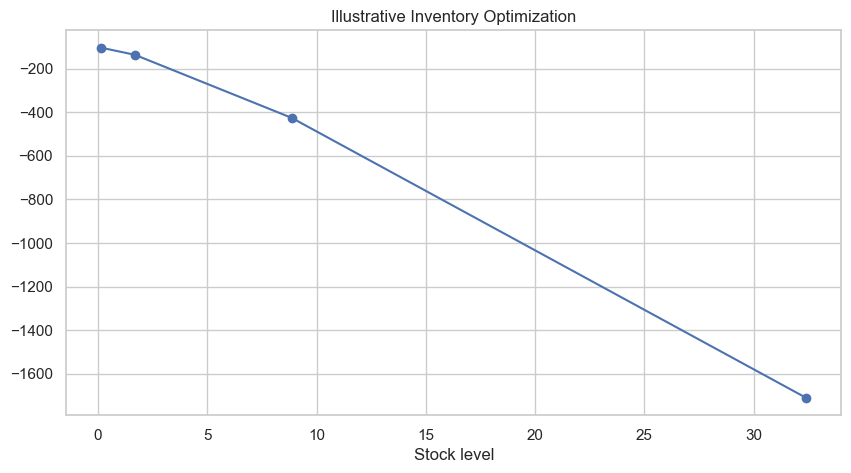

,Scenario,Stock level,Mean units sold,Mean shortage,Mean leftover,Service level
0,Low stock (P50),0.16,0.084525,6.855316,0.075475,0.502583
1,Medium stock (P75),2.92,0.979039,5.960802,1.940961,0.750025
2,High stock (P90),16.24,3.021642,3.918199,13.218358,0.900063


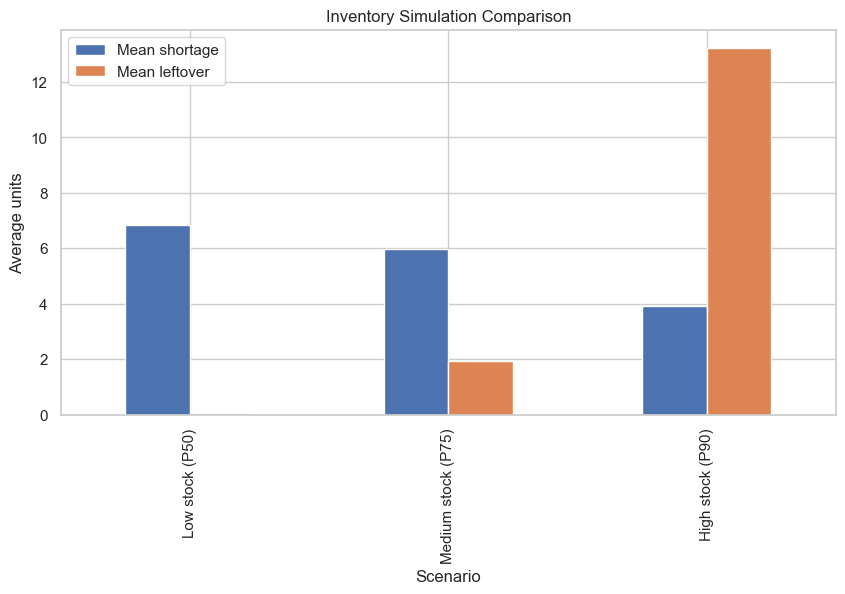

In [76]:
# Cell 33
# Illustrative model only: replace these assumptions with actual unit economics.
demand = sales.clip(lower=0).to_numpy()
if len(demand):
    candidate_stock = np.unique(np.maximum(0, np.quantile(demand, [0.50, 0.70, 0.85, 0.95])))
    unit_price, unit_cost = 100.0, 60.0
    holding_cost, shortage_cost = 5.0, 15.0
    rows = []
    for stock in candidate_stock:
        sold = np.minimum(demand, stock)
        leftover = np.maximum(stock - demand, 0)
        shortage = np.maximum(demand - stock, 0)
        profit = sold * unit_price - stock * unit_cost - leftover * holding_cost - shortage * shortage_cost
        rows.append({"Stock level": stock, "Average simulated profit": profit.mean(),
                     "Average leftover": leftover.mean(), "Average shortage": shortage.mean()})
    optimization = pd.DataFrame(rows).sort_values("Average simulated profit", ascending=False)
    display(optimization)
    optimization.plot(x="Stock level", y="Average simulated profit", marker="o", legend=False,
                      title="Illustrative Inventory Optimization")
    plt.show()

    scenarios = []
    for label, q in [("Low stock (P50)", .50), ("Medium stock (P75)", .75), ("High stock (P90)", .90)]:
        stock = float(np.quantile(demand, q))
        sold = np.minimum(demand, stock)
        scenarios.append({
            "Scenario": label, "Stock level": stock,
            "Mean units sold": sold.mean(),
            "Mean shortage": np.maximum(demand-stock, 0).mean(),
            "Mean leftover": np.maximum(stock-demand, 0).mean(),
            "Service level": (demand <= stock).mean()
        })
    simulation = pd.DataFrame(scenarios)
    display(simulation)
    simulation.set_index("Scenario")[["Mean shortage", "Mean leftover"]].plot(kind="bar",
        title="Inventory Simulation Comparison")
    plt.ylabel("Average units")
    plt.show()
else:
    print("Inventory simulation skipped: no usable sales values.")

# Cell 34
## 16. Business Intelligence dashboard (Tableau / Power BI)
Use the cleaned dataset in `clean` or export it to CSV with the following cell. Build a dashboard with:
- KPI cards: total retail sales, total warehouse sales, total retail transfers, record count
- Bar chart: retail sales by item type
- Pie chart: share of retail sales by item type
- Line chart: monthly total retail sales
- Filters: YEAR, MONTH, ITEM TYPE, SUPPLIER

In [77]:
# Cell 35
clean.to_csv("cleaned_retail_warehouse_data.csv", index=False)
print("Saved cleaned_retail_warehouse_data.csv")

Saved cleaned_retail_warehouse_data.csv


# Cell 36
## 17. Business insights, recommendations, and conclusion

After running all cells, use the displayed tables and charts to write **8–10 specific insights**. Each insight should cite a result from the actual dataset. Examples of evidence to discuss:
1. Item type with the highest total sales.
2. Item type with the highest average sales.
3. Distribution skewness and presence of outliers.
4. Correlation between retail sales and warehouse sales/transfers.
5. Regression coefficient, R², and prediction error.
6. Confidence interval for mean sales.
7. One-way ANOVA decision and p-value.
8. Forecast accuracy, only if enough monthly periods exist.
9. Inventory scenario with the best simulated profit under stated assumptions.
10. Limitations caused by the dataset's time coverage.

### Important limitations
- The screenshot shared earlier showed only **YEAR = 2020**. If the full dataset also contains only 2020, factorial ANOVA cannot estimate the year effect or the `ITEM TYPE × YEAR` interaction.
- If only one monthly period is present, time-series forecasting is not meaningful.
- Inventory prices and costs in the optimization cell are illustrative assumptions, not facts from the dataset.
- Replace the hypothesis-test benchmark with a business-approved target.
- A/B testing and a real factorial experiment require actual treatment/control observations; simulated data should not be presented as a real experiment.

### Conclusion
Complete this section after executing the notebook with the original CSV. Summarize the strongest evidence-based findings, how they can inform retail/warehouse planning, and the limitations of the dataset.